## Экстрактим фичи из картинок при помощи [SIFT](https://docs.opencv.org/4.x/da/df5/tutorial_py_sift_intro.html)

In [1]:
import sys
sys.path.append('../..')

%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import classification_report
from tqdm import tqdm
import numpy as np
from sklearn.model_selection import train_test_split

In [3]:
from src.data.utils.eda_utils import directory_to_dataframe
from src.data.utils.filter_dataset import filter_dataset


# Собираем пути до картинок в датафрейм
# Дальше будем итерироваться по датафрейму, извлекать признаки картинок, а потом мэтчить картинки на основе этих фичей
path_to_dataset = Path("../../data/01_raw/sneakers-dataset")
df = directory_to_dataframe(path_to_dataset)
# Вычищаем Yeezy Slide, т.к. они не укладываются в наши представления о кроссовках
df = filter_dataset(
    df,
    path_to_dataset,
    class_names_to_remove=['yeezy_slide'],
    bad_images_md_path='../2-exploration/bad_images.md' #Картинки, которые мы признали негодными на этапе EDA
)

df.head()

Отбросили изображений: 12
Осталось изображений: 5796


,path,sneaker_class
0,reebok_classic_leather/0071.jpg,reebok_classic_leather
1,reebok_classic_leather/0065.jpg,reebok_classic_leather
2,reebok_classic_leather/0059.jpg,reebok_classic_leather
3,reebok_classic_leather/0058.jpg,reebok_classic_leather
4,reebok_classic_leather/0064.jpg,reebok_classic_leather


In [4]:
train, test = train_test_split(df, test_size=0.2, random_state=42, shuffle=True)

In [5]:
import cv2 as cv

img_path = 'reebok_classic_leather/0004.jpg'
img = cv.imread(path_to_dataset / img_path, cv.IMREAD_GRAYSCALE)
img

array([[255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       ...,
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255]], dtype=uint8)

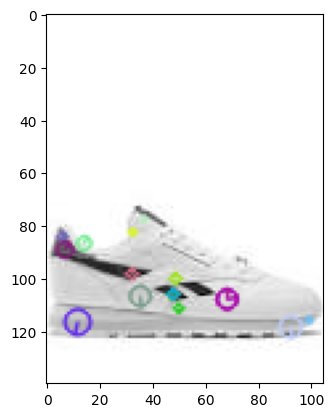

In [6]:
# Для каждого изображения в датафрейме считаем SIFT
sift = cv.SIFT_create()
keypoints, descriptors = sift.detectAndCompute(img, None)
img_with_keypoints = cv.drawKeypoints(img, keypoints, None, flags=cv.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
plt.imshow(img_with_keypoints)

In [7]:
feature_df = []
for img_path in train['path']:
    img = cv.imread(path_to_dataset / img_path, cv.IMREAD_GRAYSCALE)
    sift = cv.SIFT_create()
    keypoints, descriptors = sift.detectAndCompute(img, None)
    descriptors = pd.DataFrame(descriptors)
    descriptors['path'] = img_path
    feature_df.append(descriptors)
feature_df = pd.concat(feature_df)
feature_df

,0,1,2,3,4,5,6,7,8,9,...,119,120,121,122,123,124,125,126,127,path
0,0.0,6.0,26.0,24.0,15.0,57.0,26.0,0.0,0.0,5.0,...,35.0,2.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,nike_air_max_90/0055.jpg
1,9.0,5.0,104.0,93.0,0.0,1.0,7.0,4.0,141.0,45.0,...,0.0,81.0,141.0,57.0,0.0,0.0,0.0,0.0,0.0,nike_air_max_90/0055.jpg
2,101.0,67.0,2.0,1.0,10.0,2.0,0.0,0.0,95.0,39.0,...,14.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,nike_air_max_90/0055.jpg
3,0.0,0.0,6.0,3.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,41.0,137.0,1.0,0.0,0.0,0.0,0.0,0.0,nike_air_max_90/0055.jpg
4,0.0,0.0,0.0,4.0,79.0,127.0,17.0,0.0,2.0,0.0,...,11.0,0.0,4.0,49.0,20.0,0.0,0.0,51.0,22.0,nike_air_max_90/0055.jpg
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27,6.0,3.0,0.0,1.0,3.0,11.0,17.0,6.0,26.0,5.0,...,8.0,93.0,90.0,0.0,0.0,0.0,0.0,0.0,0.0,converse_one_star/0024.jpg
28,66.0,10.0,0.0,0.0,150.0,72.0,0.0,1.0,150.0,19.0,...,9.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,converse_one_star/0024.jpg
29,10.0,8.0,1.0,3.0,20.0,5.0,2.0,4.0,73.0,45.0,...,7.0,132.0,62.0,4.0,0.0,0.0,0.0,0.0,10.0,converse_one_star/0024.jpg
30,0.0,0.0,1.0,4.0,0.0,0.0,0.0,0.0,0.0,3.0,...,123.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,converse_one_star/0024.jpg


In [8]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

feature_df[list(range(128))] = scaler.fit_transform(feature_df[list(range(128))])
n_feats = 100
clustering = KMeans(n_feats)
clustering.fit(feature_df[list(range(128))])
feature_df['cluster_feat'] = clustering.predict(feature_df[list(range(128))]).astype(str)

/Users/a.r.makarenko/Documents/hse/sneakers-hse/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/a.r.makarenko/Documents/hse/sneakers-hse/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/a.r.makarenko/Documents/hse/sneakers-hse/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/a.r.makarenko/Documents/hse/sneakers-hse/.venv/lib/python3.13/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/a.r.makarenko/Documents/hse/sneakers-hse/.venv/lib/python3.13/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/a.r.makarenko/Documents/hse/sneake

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 10000 samples in 0.001s...
[t-SNE] Computed neighbors for 10000 samples in 0.281s...
[t-SNE] Computed conditional probabilities for sample 1000 / 10000
[t-SNE] Computed conditional probabilities for sample 2000 / 10000
[t-SNE] Computed conditional probabilities for sample 3000 / 10000
[t-SNE] Computed conditional probabilities for sample 4000 / 10000
[t-SNE] Computed conditional probabilities for sample 5000 / 10000
[t-SNE] Computed conditional probabilities for sample 6000 / 10000
[t-SNE] Computed conditional probabilities for sample 7000 / 10000
[t-SNE] Computed conditional probabilities for sample 8000 / 10000
[t-SNE] Computed conditional probabilities for sample 9000 / 10000
[t-SNE] Computed conditional probabilities for sample 10000 / 10000
[t-SNE] Mean sigma: 3.084210


/Users/a.r.makarenko/Documents/hse/sneakers-hse/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/a.r.makarenko/Documents/hse/sneakers-hse/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/a.r.makarenko/Documents/hse/sneakers-hse/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/a.r.makarenko/Documents/hse/sneakers-hse/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/a.r.makarenko/Documents/hse/sneakers-hse/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/a.r.makarenko/Documents/hse/sneakers-

[t-SNE] KL divergence after 250 iterations with early exaggeration: 94.251083
[t-SNE] KL divergence after 1000 iterations: 2.630974


/var/folders/t1/3rmgtp792xl3ffv_d2f7y7v40000gn/T/ipykernel_79656/2451772772.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  sample_df[['tsne1', 'tsne2']] = tsne.fit_transform(sample_df[list(range(128))])
/var/folders/t1/3rmgtp792xl3ffv_d2f7y7v40000gn/T/ipykernel_79656/2451772772.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  sample_df[['tsne1', 'tsne2']] = tsne.fit_transform(sample_df[list(range(128))])


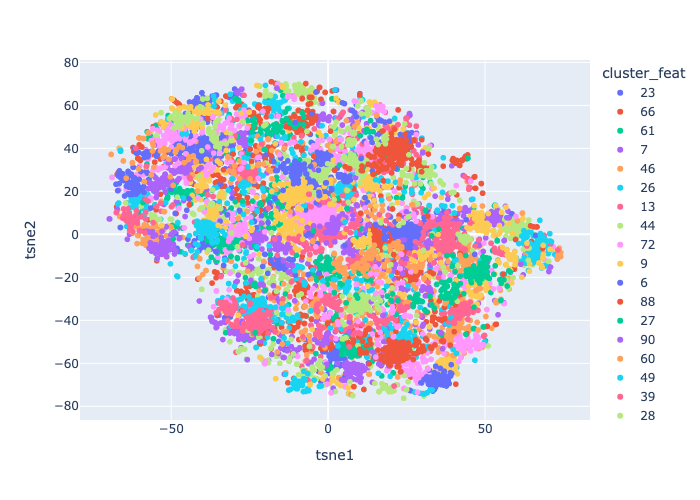

In [9]:
from sklearn.manifold import TSNE
import plotly.express as px
from IPython.display import Image, display


# Assume X is your high-dimensional data matrix and y are labels or target classes
tsne = TSNE(n_components=2, random_state=123, verbose=1)
sample_df = feature_df.sample(10000, random_state=0)
sample_df[['tsne1', 'tsne2']] = tsne.fit_transform(sample_df[list(range(128))])
fig = px.scatter(sample_df, x='tsne1', y='tsne2', color='cluster_feat')
display(Image(fig.to_image('png')))

In [ ]:
train.set_index('path', inplace=True)


KeyError: "None of ['path'] are in the columns"

In [67]:
test.set_index('path', inplace=True)

In [69]:
test_feature_df = []
for img_path in test.index:
    img = cv.imread(path_to_dataset / img_path, cv.IMREAD_GRAYSCALE)
    sift = cv.SIFT_create()
    keypoints, descriptors = sift.detectAndCompute(img, None)
    descriptors = pd.DataFrame(descriptors)
    descriptors['path'] = img_path
    test_feature_df.append(descriptors)
test_feature_df = pd.concat(test_feature_df)
test_feature_df

,0,1,2,3,4,5,6,7,8,9,...,119,120,121,122,123,124,125,126,127,path
0,68.0,76.0,4.0,1.0,7.0,22.0,5.0,1.0,167.0,145.0,...,29.0,0.0,0.0,0.0,0.0,2.0,23.0,3.0,0.0,new_balance_574/0039.jpg
1,10.0,2.0,1.0,22.0,79.0,21.0,1.0,1.0,154.0,7.0,...,19.0,0.0,0.0,0.0,0.0,0.0,5.0,6.0,0.0,new_balance_574/0039.jpg
2,10.0,48.0,7.0,4.0,13.0,16.0,0.0,0.0,133.0,76.0,...,100.0,10.0,0.0,0.0,0.0,0.0,7.0,10.0,8.0,new_balance_574/0039.jpg
3,62.0,156.0,2.0,0.0,3.0,21.0,10.0,7.0,62.0,156.0,...,34.0,1.0,1.0,0.0,0.0,0.0,36.0,31.0,1.0,new_balance_574/0039.jpg
4,6.0,1.0,0.0,2.0,5.0,10.0,8.0,5.0,126.0,1.0,...,19.0,1.0,0.0,0.0,0.0,0.0,4.0,1.0,0.0,new_balance_574/0039.jpg
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
335,33.0,45.0,16.0,6.0,6.0,3.0,0.0,3.0,24.0,34.0,...,4.0,0.0,1.0,100.0,88.0,0.0,0.0,2.0,1.0,nike_air_max_90/0121.jpg
336,23.0,0.0,2.0,3.0,2.0,3.0,109.0,129.0,5.0,6.0,...,1.0,38.0,30.0,12.0,5.0,1.0,0.0,2.0,35.0,nike_air_max_90/0121.jpg
337,4.0,14.0,9.0,1.0,0.0,0.0,0.0,0.0,16.0,5.0,...,49.0,22.0,69.0,45.0,12.0,45.0,29.0,13.0,13.0,nike_air_max_90/0121.jpg
338,0.0,0.0,17.0,18.0,12.0,16.0,1.0,0.0,55.0,53.0,...,58.0,5.0,0.0,0.0,0.0,16.0,127.0,127.0,60.0,nike_air_max_90/0121.jpg


In [70]:
test_feature_df[list(range(128))] = scaler.transform(test_feature_df[list(range(128))])
test_feature_df['cluster_feat'] = clustering.predict(test_feature_df[list(range(128))]).astype(str)

/var/folders/t1/3rmgtp792xl3ffv_d2f7y7v40000gn/T/ipykernel_48783/89987943.py:2: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`



In [85]:
train[list(range(n_feats))] = 0
for i, row in tqdm(feature_df.iterrows()):
    train.loc[row['path'], int(row['cluster_feat'])] += 1
train

352742it [00:37, 9380.50it/s]


,sneaker_class,0,1,2,3,4,5,6,7,8,...,91,92,93,94,95,96,97,98,99,joined_feats
path,,,,,,,,,,,,,,,,,,,,,
nike_air_max_90/0055.jpg,nike_air_max_90,0,4,0,3,1,0,0,0,1,...,0,0,0,0,0,0,2,0,1,38 39 13 61 3 89 23 15 99 40 87 25 39 70 4 74 ...
nike_cortez/0092.jpg,nike_cortez,1,0,0,0,0,0,1,1,0,...,0,0,1,1,0,0,0,0,0,42 6 85 93 18 94 88 59 18 88 70 70 70 59 7 58 ...
nike_blazer_mid_77/0083.jpg,nike_blazer_mid_77,8,0,0,2,2,1,1,1,0,...,0,0,0,1,2,0,2,1,0,53 3 4 97 34 29 44 49 95 34 29 0 57 14 50 67 0...
converse_one_star/0005.jpg,converse_one_star,6,0,0,0,2,0,1,3,0,...,0,1,0,5,1,0,1,1,0,81 94 69 68 46 81 20 83 76 81 94 20 7 94 84 73...
nike_air_jordan_11/0047.jpg,nike_air_jordan_11,0,1,0,3,0,0,0,0,0,...,0,1,0,0,0,0,0,0,2,3 90 58 34 16 82 42 38 99 56 14 90 58 53 64 51...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
converse_chuck_taylor_all-star_low/0092.jpg,converse_chuck_taylor_all-star_low,0,0,5,1,2,0,1,0,1,...,0,0,3,1,2,0,3,0,1,48 10 48 13 10 13 69 42 66 61 87 58 58 58 90 5...
nike_air_force_1_low/0042.jpg,nike_air_force_1_low,2,1,0,6,0,7,0,0,5,...,1,1,0,2,2,2,3,0,0,33 25 18 43 43 81 81 18 1 65 86 30 94 50 57 5 ...
converse_chuck_70_high/0072.jpg,converse_chuck_70_high,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,24 61 24 79 79 79 62 40 28 88 38 82 22 78 80 3...


In [93]:
from sklearn.feature_extraction.text import TfidfTransformer

tfidf = TfidfTransformer()

train[list(range(n_feats))] = tfidf.fit_transform(train[list(range(n_feats))]).toarray()
train

,sneaker_class,0,1,2,3,4,5,6,7,8,...,91,92,93,94,95,96,97,98,99,joined_feats
path,,,,,,,,,,,,,,,,,,,,,
nike_air_max_90/0055.jpg,nike_air_max_90,0.000000,0.287535,0.000000,0.220965,0.074561,0.000000,0.000000,0.000000,0.077979,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.156984,0.000000,0.079285,38 39 13 61 3 89 23 15 99 40 87 25 39 70 4 74 ...
nike_cortez/0092.jpg,nike_cortez,0.138791,0.000000,0.000000,0.000000,0.000000,0.000000,0.203783,0.160971,0.000000,...,0.000000,0.000000,0.167541,0.179230,0.000000,0.000000,0.000000,0.000000,0.000000,42 6 85 93 18 94 88 59 18 88 70 70 70 59 7 58 ...
nike_blazer_mid_77/0083.jpg,nike_blazer_mid_77,0.530538,0.000000,0.000000,0.172716,0.174840,0.095100,0.097372,0.076915,0.000000,...,0.000000,0.000000,0.000000,0.085640,0.198716,0.000000,0.184057,0.106262,0.000000,53 3 4 97 34 29 44 49 95 34 29 0 57 14 50 67 0...
converse_one_star/0005.jpg,converse_one_star,0.253372,0.000000,0.000000,0.000000,0.111332,0.000000,0.062003,0.146931,0.000000,...,0.000000,0.060360,0.000000,0.272664,0.063268,0.000000,0.058601,0.067664,0.000000,81 94 69 68 46 81 20 83 76 81 94 20 7 94 84 73...
nike_air_jordan_11/0047.jpg,nike_air_jordan_11,0.000000,0.077024,0.000000,0.236765,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.086629,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.169908,3 90 58 34 16 82 42 38 99 56 14 90 58 53 64 51...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
converse_chuck_taylor_all-star_low/0092.jpg,converse_chuck_taylor_all-star_low,0.000000,0.000000,0.237428,0.044152,0.089390,0.000000,0.049783,0.000000,0.046744,...,0.000000,0.000000,0.122788,0.043785,0.101597,0.000000,0.141153,0.000000,0.047527,48 10 48 13 10 13 69 42 66 61 87 58 58 58 90 5...
nike_air_force_1_low/0042.jpg,nike_air_force_1_low,0.066188,0.042058,0.000000,0.258570,0.000000,0.332201,0.000000,0.000000,0.228124,...,0.054989,0.047304,0.000000,0.085473,0.099164,0.101684,0.137774,0.000000,0.000000,33 25 18 43 43 81 81 18 1 65 86 30 94 50 57 5 ...
converse_chuck_70_high/0072.jpg,converse_chuck_70_high,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.173490,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,24 61 24 79 79 79 62 40 28 88 38 82 22 78 80 3...


In [ ]:
test[list(range(n_feats))] = 0
for i, row in tqdm(test_feature_df.iterrows()):
    test.loc[row['path'], int(row['cluster_feat'])] += 1
test

87615it [00:09, 9368.18it/s]


,sneaker_class,0,1,2,3,4,5,6,7,8,...,92,93,94,95,96,97,98,99,pred,joined_feats
path,,,,,,,,,,,,,,,,,,,,,
new_balance_574/0039.jpg,new_balance_574,3,1,0,1,0,1,1,3,0,...,0,4,0,0,0,0,1,0,yeezy_700_wave_runner,7 18 0 40 71 11 0 85 43 78 28 64 80 3 53 49 9 ...
nike_air_jordan_11/0041.jpg,nike_air_jordan_11,2,0,0,0,6,0,0,0,0,...,0,0,0,0,0,1,0,0,adidas_gazelle,44 71 97 0 80 0 4 84 4 4 63 54 89 4 19 31 28 3...
adidas_ultraboost/0076.jpg,adidas_ultraboost,5,2,0,3,0,0,1,2,0,...,2,2,0,0,1,1,0,0,new_balance_550,0 66 31 32 51 80 72 79 40 28 44 80 93 3 7 31 6...
vans_old_skool/0036.jpg,vans_old_skool,2,0,0,1,10,7,1,3,7,...,2,2,0,0,11,1,8,0,nike_dunk_high,41 62 55 0 62 7 98 41 9 30 10 84 87 54 18 44 3...
nike_air_force_1_low/0115.jpg,nike_air_force_1_low,4,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,vans_slip-on_checkerboard,99 42 13 58 38 39 55 48 71 10 61 10 16 48 0 0 0 0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
new_balance_550/0049.jpg,new_balance_550,0,2,0,3,0,0,0,0,0,...,0,1,0,1,0,0,0,0,vans_slip-on_checkerboard,85 93 64 64 3 43 18 1 61 3 1 89 36 58 89 38 28...
salomon_xt-6/0090.jpg,salomon_xt-6,0,0,0,1,0,1,0,0,0,...,0,1,1,0,0,1,0,0,asics_gel-lyte_iii,13 43 36 75 97 43 47 38 39 54 51 29 42 53 78 1...
adidas_gazelle/0067.jpg,adidas_gazelle,1,0,1,0,0,0,0,1,0,...,2,0,0,0,0,0,0,0,adidas_forum_high,13 46 10 90 58 0 56 41 46 86 69 43 18 79 79 79...


In [ ]:
test[list(range(n_feats))] = tfidf.transform(test[list(range(n_feats))]).toarray()
test

,sneaker_class,0,1,2,3,4,5,6,7,8,...,92,93,94,95,96,97,98,99,pred,joined_feats
path,,,,,,,,,,,,,,,,,,,,,
new_balance_574/0039.jpg,new_balance_574,0.128159,0.054291,0.000000,0.055629,0.000000,0.061260,0.062724,0.148639,0.000000,...,0.000000,0.206275,0.000000,0.000000,0.000000,0.000000,0.068451,0.00000,adidas_samba,7 18 0 40 71 11 0 85 43 78 28 64 80 3 53 49 9 ...
nike_air_jordan_11/0041.jpg,nike_air_jordan_11,0.171920,0.000000,0.000000,0.000000,0.679876,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.119287,0.000000,0.00000,converse_chuck_70_low,44 71 97 0 80 0 4 84 4 4 63 54 89 4 19 31 28 3...
adidas_ultraboost/0076.jpg,adidas_ultraboost,0.262473,0.133428,0.000000,0.205074,0.000000,0.000000,0.077076,0.121767,0.000000,...,0.150068,0.126738,0.000000,0.000000,0.080647,0.072847,0.000000,0.00000,reebok_club_c_85,0 66 31 32 51 80 72 79 40 28 44 80 93 3 7 31 6...
vans_old_skool/0036.jpg,vans_old_skool,0.045123,0.000000,0.000000,0.029380,0.297409,0.226476,0.033127,0.078502,0.217730,...,0.064498,0.054471,0.000000,0.000000,0.381274,0.031309,0.289209,0.00000,vans_sk8-hi,41 62 55 0 62 7 98 41 9 30 10 84 87 54 18 44 3...
nike_air_force_1_low/0115.jpg,nike_air_force_1_low,0.580341,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.20337,vans_authentic,99 42 13 58 38 39 55 48 71 10 61 10 16 48 0 0 0 0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
new_balance_550/0049.jpg,new_balance_550,0.000000,0.212953,0.000000,0.327302,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.101137,0.000000,0.125524,0.000000,0.000000,0.000000,0.00000,salomon_xt-6,85 93 64 64 3 43 18 1 61 3 1 89 36 58 89 38 28...
salomon_xt-6/0090.jpg,salomon_xt-6,0.000000,0.000000,0.000000,0.111527,0.000000,0.122817,0.000000,0.000000,0.000000,...,0.000000,0.103387,0.110600,0.000000,0.000000,0.118851,0.000000,0.00000,new_balance_327,13 43 36 75 97 43 47 38 39 54 51 29 42 53 78 1...
adidas_gazelle/0067.jpg,adidas_gazelle,0.104845,0.000000,0.146836,0.000000,0.000000,0.000000,0.000000,0.121600,0.000000,...,0.299723,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,adidas_forum_high,13 46 10 90 58 0 56 41 46 86 69 43 18 79 79 79...


In [133]:
from sklearn.svm import LinearSVC, SVC

svc = LinearSVC(loss='squared_hinge', C=1, random_state=42)

# svc = SVC(C=1, kernel='poly')
svc.fit(train[list(range(n_feats))], train['sneaker_class'])

train['pred'] = svc.predict(train[list(range(n_feats))])
print(classification_report(train['sneaker_class'], train['pred']))

                                     precision    recall  f1-score   support

                  adidas_forum_high       0.27      0.44      0.34       124
                   adidas_forum_low       0.44      0.28      0.34        75
                     adidas_gazelle       0.30      0.53      0.39       116
                      adidas_nmd_r1       0.43      0.38      0.40        69
                       adidas_samba       0.41      0.23      0.29        57
                  adidas_stan_smith       0.25      0.25      0.25       114
                   adidas_superstar       0.35      0.28      0.31        80
                  adidas_ultraboost       0.27      0.28      0.28       121
                 asics_gel-lyte_iii       0.39      0.25      0.31        71
             converse_chuck_70_high       0.47      0.26      0.34        68
              converse_chuck_70_low       0.38      0.41      0.40       109
converse_chuck_taylor_all-star_high       0.41      0.69      0.52        6

/Users/a.r.makarenko/Documents/hse/sneakers-hse/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning:

divide by zero encountered in matmul

/Users/a.r.makarenko/Documents/hse/sneakers-hse/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning:

overflow encountered in matmul

/Users/a.r.makarenko/Documents/hse/sneakers-hse/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning:

invalid value encountered in matmul



In [134]:
test['pred'] = svc.predict(test[list(range(n_feats))])
print(classification_report(test['sneaker_class'], test['pred']))


                                     precision    recall  f1-score   support

                  adidas_forum_high       0.06      0.04      0.05        24
                   adidas_forum_low       0.00      0.00      0.00        16
                     adidas_gazelle       0.22      0.30      0.26        33
                      adidas_nmd_r1       0.50      0.15      0.24        26
                       adidas_samba       0.00      0.00      0.00        16
                  adidas_stan_smith       0.44      0.21      0.29        33
                   adidas_superstar       0.09      0.08      0.08        13
                  adidas_ultraboost       0.16      0.18      0.17        28
                 asics_gel-lyte_iii       0.00      0.00      0.00        20
             converse_chuck_70_high       0.20      0.14      0.17         7
              converse_chuck_70_low       0.33      0.15      0.21        39
converse_chuck_taylor_all-star_high       0.14      0.44      0.21         

/Users/a.r.makarenko/Documents/hse/sneakers-hse/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning:

divide by zero encountered in matmul

/Users/a.r.makarenko/Documents/hse/sneakers-hse/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning:

overflow encountered in matmul

/Users/a.r.makarenko/Documents/hse/sneakers-hse/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning:

invalid value encountered in matmul



In [146]:
from sklearn.model_selection import cross_val_score

# 1 — 0.18
Cs = [0.1, 1, 10, 100, 1000, 10000]
cv_accuracy = []
for C in Cs:
    svc = SVC(C=C, kernel='rbf')
    X = train[list(range(n_feats))]
    y = train['sneaker_class']
    cv_accuracy.append(cross_val_score(svc, X, y).mean())
cv_accuracy

[0.041629003459435335,
 0.19499637317263702,
 0.1965070862626939,
 0.19672306848194027,
 0.19672306848194027,
 0.19672306848194027]

In [ ]:
Cs = [0.1, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 1, 10]
cv_accuracy = []
for C in Cs:
    svc = SVC(C=C, kernel='poly', degree=3)
    X = train[list(range(n_feats))]
    y = train['sneaker_class']
    cv_accuracy.append(cross_val_score(svc, X, y).mean())
cv_accuracy

[0.11410905590893874,
 0.19478132090912473,
 0.19737008518394522,
 0.1999588494587658,
 0.2010385280660641,
 0.2001736692333445,
 0.19629203399918166,
 0.19629203399918163,
 0.19370466465796227]

In [155]:
Cs = [0.1, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 1, 10]
cv_accuracy = []
for C in Cs:
    svc = SVC(C=C, kernel='poly', degree=2)
    X = train[list(range(n_feats))]
    y = train['sneaker_class']
    cv_accuracy.append(cross_val_score(svc, X, y).mean())
cv_accuracy

[0.12899206747758807,
 0.19176059219581149,
 0.19413244429565152,
 0.1932694453744002,
 0.1956419949410408,
 0.19736683033887586,
 0.19672051110367145,
 0.1926226611613287,
 0.1842112115463304]

In [148]:
Cs = [0.1, 1, 10, 100, 1000, 10000]
cv_accuracy = []
for C in Cs:
    svc = SVC(C=C, kernel='linear')
    X = train[list(range(n_feats))]
    y = train['sneaker_class']
    cv_accuracy.append(cross_val_score(svc, X, y).mean())
cv_accuracy

[0.09232391288174682,
 0.17881770077744302,
 0.14775764423613436,
 0.13222645352081241,
 0.1309321876278689,
 0.1309321876278689]

In [149]:
Cs = [0.1, 1, 10, 100, 1000, 10000]
cv_accuracy = []
for C in Cs:
    svc = SVC(C=C, kernel='sigmoid')
    X = train[list(range(n_feats))]
    y = train['sneaker_class']
    cv_accuracy.append(cross_val_score(svc, X, y).mean())
cv_accuracy

[0.10569481642673809,
 0.1624239761187367,
 0.12165773909161925,
 0.11238561544470485,
 0.10979638619201726,
 0.10893454971543355]

In [153]:
svc = SVC(C=0.6, kernel='poly')
svc.fit(X, y)
test['pred'] = svc.predict(test[list(range(n_feats))])
print(classification_report(test['sneaker_class'], test['pred']))

                                     precision    recall  f1-score   support

                  adidas_forum_high       0.00      0.00      0.00        24
                   adidas_forum_low       0.00      0.00      0.00        16
                     adidas_gazelle       0.32      0.24      0.28        33
                      adidas_nmd_r1       0.56      0.19      0.29        26
                       adidas_samba       0.25      0.06      0.10        16
                  adidas_stan_smith       0.26      0.27      0.27        33
                   adidas_superstar       0.12      0.08      0.10        13
                  adidas_ultraboost       0.20      0.36      0.26        28
                 asics_gel-lyte_iii       0.13      0.15      0.14        20
             converse_chuck_70_high       0.17      0.29      0.21         7
              converse_chuck_70_low       0.28      0.26      0.27        39
converse_chuck_taylor_all-star_high       0.25      0.11      0.15         

In [166]:
from sklearn.ensemble import RandomForestClassifier

X = train[list(range(n_feats))]
y = train['sneaker_class']

forest = RandomForestClassifier(n_estimators=1000, random_state=42, n_jobs=5)
cross_val_score(forest, X, y)#.mean()

array([0.19181034, 0.17044229, 0.17259978, 0.17475728, 0.18985976])

In [165]:
from sklearn.ensemble import ExtraTreesClassifier

extra = ExtraTreesClassifier(n_estimators=1000, random_state=42)
cross_val_score(extra, X, y)#.mean()

array([0.19288793, 0.18554477, 0.18662352, 0.19201726, 0.20064725])